# NB11b — Fusión con densidad **a nivel mama** (réplica exacta del Hito 2)

## Propósito

Complementar el NB11 con la versión simétrica al Hito 2 (NB07): la fusión con densidad se aplica **a nivel mama**, antes de agregar a estudio. Esto permite responder rigurosamente:

1. **¿Se reproduce el AUC 0.7067 de `M_A_mlp_dens` del Hito 2 cuando hacemos la fusión también a nivel mama con nuestros mejores modelos?**
2. **¿La diferencia observada en el NB11 (sin mejora por densidad) era artefacto del cambio de nivel de evaluación, o es un hallazgo robusto?**
3. **¿Qué pasa si fusionamos a nivel mama y luego agregamos a estudio?** Comparación con la fusión directa a nivel estudio del NB11.

## Diseño

Los mismos 3 candidatos del NB11 (predicciones a nivel mama) y los mismos 3 modelos de fusión (LogReg, HistGB, MLP), pero ahora:

- Features de fusión: `[pred_mama, dens_A_mama, dens_B_mama, dens_C_mama, dens_D_mama]` (5 features)
- Entrenamiento: 7998 mamas del training pool
- Evaluación: 2000 mamas del test pool — AUC directo a nivel mama
- Bonus: agregar las fusiones a estudio con max(L,R) y reportar AUC a nivel estudio

## Salidas

- `Outputs/Predicciones_v2/fusion_resultados_mama.csv` — métricas completas a nivel mama
- `Outputs/Predicciones_v2/fusion_resultados_mama_agregadas.csv` — métricas tras agregar a estudio
- `Outputs/Predicciones_v2/fusion_densidad_mama/` — predicciones guardadas
- `Outputs/Predicciones_v2/fusion_mama_vs_estudio.png` — comparación visual


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2  = os.path.join(OUTPUTS, 'Predicciones_v2')
PRED_DIR_V1  = os.path.join(OUTPUTS, 'Predicciones')
FUSION_DIR_M = os.path.join(PRED_DIR_V2, 'fusion_densidad_mama')
NB_DIR    = os.path.join(BASE, 'src')

os.makedirs(FUSION_DIR_M, exist_ok=True)
sys.path.insert(0, NB_DIR)
from tfm_eval import (  # noqa: E402
    bootstrap_metric_ci, ece_score, delong_test,
    aggregate_breast_to_study, compute_full_metrics, SEED,
)

np.random.seed(SEED)
print(f'FUSION_DIR_M: {FUSION_DIR_M}')

FUSION_DIR_M: C:\Users\victo\Documents\TFM\Proyecto\Outputs\Predicciones_v2\fusion_densidad_mama


## 1. Cargar metadata, etiquetas y densidad a nivel mama

**Importante**: el orden es L primero (índices 0..N-1), R después (índices N..2N-1), igual que en NB09 y NB10.

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)

# Nivel estudio (para agregar después)
is_train_E = (meta['split'].values == 'training')
is_test_E  = (meta['split'].values == 'test')
y_E_test   = meta['y_estudio'].values[is_test_E].astype(int)
study_ids_E_test = meta['study_id'].values[is_test_E]

# Nivel mama: L primero, R después
y_M = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
split_M = np.concatenate([meta['split'].values, meta['split'].values])
is_train_M = (split_M == 'training')
is_test_M  = (split_M == 'test')
density_M  = np.concatenate([meta['density_L'].values, meta['density_R'].values])

y_M_train = y_M[is_train_M]
y_M_test  = y_M[is_test_M]
density_M_train = density_M[is_train_M]
density_M_test  = density_M[is_test_M]

print(f'Nivel mama:  train={is_train_M.sum()} (pos={int(y_M_train.sum())})  '
      f'test={is_test_M.sum()} (pos={int(y_M_test.sum())})')
print(f'Densidad mama train: {pd.Series(density_M_train).value_counts(dropna=False).to_dict()}')
print(f'Densidad mama test:  {pd.Series(density_M_test).value_counts(dropna=False).to_dict()}')

# One-hot codificación de densidad (4 columnas A/B/C/D fijas)
def one_hot_density(d):
    df = pd.get_dummies(pd.Series(d), prefix='dens')
    for c in ['dens_A', 'dens_B', 'dens_C', 'dens_D']:
        if c not in df.columns: df[c] = 0
    return df[['dens_A', 'dens_B', 'dens_C', 'dens_D']].values.astype(np.float32)

D_M_train = one_hot_density(density_M_train)
D_M_test  = one_hot_density(density_M_test)
print(f'\nOne-hot density (mama): train={D_M_train.shape}  test={D_M_test.shape}')

Nivel mama:  train=7998 (pos=395)  test=2000 (pos=99)
Densidad mama train: {'C': 6114, 'D': 1080, 'B': 764, 'A': 40}
Densidad mama test:  {'C': 1530, 'D': 270, 'B': 190, 'A': 10}

One-hot density (mama): train=(7998, 4)  test=(2000, 4)


## 2. Cargar predicciones de los 3 candidatos (a nivel mama, SIN agregar)

In [3]:
CANDIDATOS = [
    ('M_A_22', 'xgb'),
    ('M_A_gg', 'mlp'),
    ('M_A_22', 'rf'),
]

def load_mama(config, head):
    """Carga predicciones a nivel mama (sin agregar): (oof_7998, test_2000)."""
    oof  = np.load(os.path.join(PRED_DIR_V2, f'{config}__{head}_oof.npy'))
    test = np.load(os.path.join(PRED_DIR_V2, f'{config}__{head}_test.npy'))
    return oof, test

base_preds_M = {}
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    oof, test = load_mama(cfg, head)
    auc_base_M = roc_auc_score(y_M_test, test)
    # Agregar a estudio para tener la referencia E también
    test_agg, _ = aggregate_breast_to_study(test, study_ids_E_test, agg='max')
    auc_base_E = roc_auc_score(y_E_test, test_agg)
    base_preds_M[key] = {'oof': oof, 'test': test, 'test_agg': test_agg,
                          'auc_base_M': auc_base_M, 'auc_base_E': auc_base_E}
    print(f'{key:18s}  AUC base mama={auc_base_M:.4f}  AUC base estudio (agg max)={auc_base_E:.4f}')

M_A_22__xgb         AUC base mama=0.6813  AUC base estudio (agg max)=0.6891
M_A_gg__mlp         AUC base mama=0.6866  AUC base estudio (agg max)=0.6553
M_A_22__rf          AUC base mama=0.6803  AUC base estudio (agg max)=0.6679


## 3. Baseline: densidad sola como predictor a nivel mama

In [4]:
dens_ord_M_test = np.array([{'A':0,'B':1,'C':2,'D':3}.get(d, -1) for d in density_M_test])
auc_dens_solo_M = roc_auc_score(y_M_test, dens_ord_M_test)
auc_dens_inv_M  = roc_auc_score(y_M_test, -dens_ord_M_test)
print(f'Baseline: solo densidad mama (ordinal)   AUC = {auc_dens_solo_M:.4f}')
print(f'Baseline: densidad mama invertida        AUC = {auc_dens_inv_M:.4f}')

Baseline: solo densidad mama (ordinal)   AUC = 0.4600
Baseline: densidad mama invertida        AUC = 0.5400


## 4. Modelos de fusión a nivel mama (mismos 3 del NB11)

In [5]:
def build_fusion_features(pred, D):
    return np.column_stack([pred.reshape(-1, 1), D]).astype(np.float32)

def fit_predict_fusion(pred_oof, pred_test, D_train, D_test, y_train, model_name):
    X_train = build_fusion_features(pred_oof, D_train)
    X_test  = build_fusion_features(pred_test, D_test)
    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train); X_test_s = sc.transform(X_test)
    if model_name == 'logreg':
        clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                  random_state=SEED, solver='lbfgs')
    elif model_name == 'histgb':
        clf = HistGradientBoostingClassifier(max_leaf_nodes=15, learning_rate=0.05,
                                             max_iter=200, class_weight='balanced', random_state=SEED)
    elif model_name == 'mlp':
        clf = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=SEED,
                            learning_rate_init=0.01, early_stopping=True, validation_fraction=0.15)
    clf.fit(X_train_s, y_train)
    return clf.predict_proba(X_test_s)[:, 1]

FUSION_MODELS = ['logreg', 'histgb', 'mlp']

fusion_preds_M = {}
for key, d in base_preds_M.items():
    for fm in FUSION_MODELS:
        pred_fusion_M = fit_predict_fusion(
            d['oof'], d['test'], D_M_train, D_M_test, y_M_train, fm
        )
        fusion_preds_M[f'{key}__fuse_{fm}'] = pred_fusion_M
        # Guardar a disco
        cfg_str = key.replace('__', '_')
        np.save(os.path.join(FUSION_DIR_M, f'{cfg_str}__fuse_{fm}_test.npy'), pred_fusion_M)

print(f'Modelos de fusión entrenados a nivel mama: {len(fusion_preds_M)}')

Modelos de fusión entrenados a nivel mama: 9


## 5. Tabla maestra — métricas A NIVEL MAMA (2000 mamas test)

In [6]:
rows_M = []
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    base_test = base_preds_M[key]['test']
    m_base = compute_full_metrics(y_M_test, base_test, n_boot=1000)
    rows_M.append({'candidato': key, 'modelo_fusion': 'NINGUNO_base',
                   **m_base, 'delta_vs_base': 0.0, 'p_delong_vs_base': np.nan})
    for fm in FUSION_MODELS:
        pf = fusion_preds_M[f'{key}__fuse_{fm}']
        m_f = compute_full_metrics(y_M_test, pf, n_boot=1000)
        d = delong_test(y_M_test, pf, base_test)
        rows_M.append({'candidato': key, 'modelo_fusion': fm, **m_f,
                       'delta_vs_base': d['delta'], 'p_delong_vs_base': d['p_value']})

df_fusion_M = pd.DataFrame(rows_M)
df_fusion_M.to_csv(os.path.join(PRED_DIR_V2, 'fusion_resultados_mama.csv'), index=False)

print('=' * 110)
print('NIVEL MAMA (2000 mamas test) — ¿la fusión con densidad mejora respecto al base, igual que en Hito 2?')
print('=' * 110)
print(f'{"Candidato":<20s} {"Fusión":<14s} {"AUC [IC95%]":<24s} {"Brier":<8s} {"ECE":<8s} {"Δ vs base":<12s} {"p_DeLong":<10s}')
print('-' * 110)
for _, r in df_fusion_M.iterrows():
    delta_str = f'{r["delta_vs_base"]:+.4f}' if r['modelo_fusion'] != 'NINGUNO_base' else '   -    '
    p_str    = f'{r["p_delong_vs_base"]:.4f}' if not pd.isna(r['p_delong_vs_base']) else '   -    '
    sig = '★' if (not pd.isna(r['p_delong_vs_base']) and r['p_delong_vs_base'] < 0.05) else ' '
    print(f'  {sig}{r["candidato"]:<19s} {r["modelo_fusion"]:<14s} '
          f'{r["auc"]:.4f} [{r["auc_lo"]:.4f},{r["auc_hi"]:.4f}]  '
          f'{r["brier"]:.4f}  {r["ece"]:.4f}  {delta_str:<12s} {p_str}')

NIVEL MAMA (2000 mamas test) — ¿la fusión con densidad mejora respecto al base, igual que en Hito 2?
Candidato            Fusión         AUC [IC95%]              Brier    ECE      Δ vs base    p_DeLong  
--------------------------------------------------------------------------------------------------------------
   M_A_22__xgb         NINGUNO_base   0.6813 [0.6181,0.7440]  0.1175  0.2755     -            -    
   M_A_22__xgb         logreg         0.6784 [0.6193,0.7370]  0.2224  0.4222  -0.0029      0.8640
   M_A_22__xgb         histgb         0.6484 [0.5813,0.7092]  0.1555  0.3049  -0.0330      0.3887
   M_A_22__xgb         mlp            0.6482 [0.5830,0.7086]  0.0417  0.0062  -0.0332      0.3297
   M_A_gg__mlp         NINGUNO_base   0.6866 [0.6289,0.7417]  0.1943  0.3811     -            -    
   M_A_gg__mlp         logreg         0.6939 [0.6356,0.7467]  0.2169  0.4113  +0.0073      0.5722
  ★M_A_gg__mlp         histgb         0.6271 [0.5631,0.6911]  0.1889  0.3457  -0.0596      0.

## 6. Comparación directa contra `M_A_mlp_dens` del Hito 2 a NIVEL MAMA

Esta es la comparación más equitativa posible con el Hito 2: mismo nivel (mama), mismo conjunto de muestras (2000), mismo tipo de modelo (fusión con densidad). Si replicamos los 0.7067 con nuestros mejores candidatos, confirmamos que el Hito 2 era reproducible. Si no, identificamos por qué.

In [7]:
try:
    pred_hito2_M = np.load(os.path.join(PRED_DIR_V1, 'M_A_mlp_dens_test.npy'))
    auc_hito2_M = roc_auc_score(y_M_test, pred_hito2_M)
    print(f'Hito 2 M_A_mlp_dens AUC a nivel mama: {auc_hito2_M:.4f}')
    print()
    
    print('=' * 100)
    print(f'{"Candidato":<22s} {"Fusión":<10s} {"AUC NB11b":<11s} {"AUC H2":<11s} {"Δ":<10s} {"p_DeLong":<10s}')
    print('=' * 100)
    h2_vs_rows = []
    for cfg, head in CANDIDATOS:
        key = f'{cfg}__{head}'
        for fm in FUSION_MODELS:
            pf = fusion_preds_M[f'{key}__fuse_{fm}']
            d  = delong_test(y_M_test, pf, pred_hito2_M)
            h2_vs_rows.append({'candidato': key, 'modelo_fusion': fm,
                                'auc_nb11b': d['auc_a'], 'auc_hito2': d['auc_b'],
                                'delta_nb11b_minus_h2': d['delta'], 'p_delong': d['p_value']})
            sig = '★' if d['p_value'] < 0.05 else ' '
            print(f'  {sig}{key:<21s} {fm:<10s} {d["auc_a"]:.4f}     {d["auc_b"]:.4f}     '
                  f'{d["delta"]:+.4f}    {d["p_value"]:.4f}')
    pd.DataFrame(h2_vs_rows).to_csv(os.path.join(PRED_DIR_V2, 'fusion_mama_vs_hito2.csv'), index=False)
except FileNotFoundError as e:
    print(f'No se pudo cargar Hito 2: {e}')
    auc_hito2_M = None
    pred_hito2_M = None

Hito 2 M_A_mlp_dens AUC a nivel mama: 0.7067

Candidato              Fusión     AUC NB11b   AUC H2      Δ          p_DeLong  
   M_A_22__xgb           logreg     0.6784     0.7067     -0.0283    0.2932
   M_A_22__xgb           histgb     0.6484     0.7067     -0.0584    0.0774
   M_A_22__xgb           mlp        0.6482     0.7067     -0.0586    0.0796
   M_A_gg__mlp           logreg     0.6939     0.7067     -0.0128    0.5242
  ★M_A_gg__mlp           histgb     0.6271     0.7067     -0.0797    0.0039
   M_A_gg__mlp           mlp        0.6841     0.7067     -0.0226    0.2718
   M_A_22__rf            logreg     0.6781     0.7067     -0.0287    0.2830
  ★M_A_22__rf            histgb     0.6219     0.7067     -0.0848    0.0090
   M_A_22__rf            mlp        0.6780     0.7067     -0.0287    0.2444


## 7. Bonus: agregar las fusiones del NB11b a nivel estudio y comparar con NB11

Pregunta: ¿es **mejor fusionar a nivel mama y luego agregar**, o **agregar primero a nivel estudio y luego fusionar**? El NB11 hizo lo segundo; aquí evaluamos lo primero.

In [8]:
rows_E_via_M = []
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    base_E_agg = base_preds_M[key]['test_agg']
    auc_base_E = roc_auc_score(y_E_test, base_E_agg)
    rows_E_via_M.append({'candidato': key, 'modelo_fusion': 'NINGUNO_base',
                          'auc_E_via_aggregate': auc_base_E, 'delta_vs_base': 0.0, 'p_delong_vs_base': np.nan})
    for fm in FUSION_MODELS:
        # Tomar predicciones fusion a nivel mama y agregar a estudio
        pf_M = fusion_preds_M[f'{key}__fuse_{fm}']
        pf_E, _ = aggregate_breast_to_study(pf_M, study_ids_E_test, agg='max')
        auc_fE = roc_auc_score(y_E_test, pf_E)
        d = delong_test(y_E_test, pf_E, base_E_agg)
        rows_E_via_M.append({'candidato': key, 'modelo_fusion': fm,
                              'auc_E_via_aggregate': auc_fE,
                              'delta_vs_base': d['delta'], 'p_delong_vs_base': d['p_value']})

df_E_via_M = pd.DataFrame(rows_E_via_M)
df_E_via_M.to_csv(os.path.join(PRED_DIR_V2, 'fusion_resultados_mama_agregadas.csv'), index=False)

print('=' * 100)
print('FUSIÓN A NIVEL MAMA + AGREGACIÓN A ESTUDIO con max(L,R)')
print('=' * 100)
print(f'{"Candidato":<20s} {"Fusión":<14s} {"AUC estudio":<15s} {"Δ vs base":<12s} {"p_DeLong":<10s}')
for _, r in df_E_via_M.iterrows():
    delta_str = f'{r["delta_vs_base"]:+.4f}' if r['modelo_fusion'] != 'NINGUNO_base' else '   -    '
    p_str    = f'{r["p_delong_vs_base"]:.4f}' if not pd.isna(r['p_delong_vs_base']) else '   -    '
    sig = '★' if (not pd.isna(r['p_delong_vs_base']) and r['p_delong_vs_base'] < 0.05) else ' '
    print(f'  {sig}{r["candidato"]:<19s} {r["modelo_fusion"]:<14s} '
          f'{r["auc_E_via_aggregate"]:.4f}          {delta_str:<12s} {p_str}')

FUSIÓN A NIVEL MAMA + AGREGACIÓN A ESTUDIO con max(L,R)
Candidato            Fusión         AUC estudio     Δ vs base    p_DeLong  
   M_A_22__xgb         NINGUNO_base   0.6891             -            -    
   M_A_22__xgb         logreg         0.6854          -0.0037      0.8308
   M_A_22__xgb         histgb         0.6365          -0.0526      0.1563
   M_A_22__xgb         mlp            0.6644          -0.0247      0.3628
   M_A_gg__mlp         NINGUNO_base   0.6553             -            -    
   M_A_gg__mlp         logreg         0.6714          +0.0161      0.1774
   M_A_gg__mlp         histgb         0.6425          -0.0128      0.6494
   M_A_gg__mlp         mlp            0.6651          +0.0098      0.4361
   M_A_22__rf          NINGUNO_base   0.6679             -            -    
   M_A_22__rf          logreg         0.6729          +0.0050      0.6564
  ★M_A_22__rf          histgb         0.5991          -0.0688      0.0133
   M_A_22__rf          mlp            0.6729    

## 8. Comparación lado a lado: NB11 (fusión en E) vs NB11b (fusión en M, agregado a E)

Carga los resultados del NB11 ya generados y los compara con los del NB11b agregados.

In [9]:
try:
    df_nb11 = pd.read_csv(os.path.join(PRED_DIR_V2, 'fusion_resultados.csv'))
    # Pivot del NB11 sobre la columna AUC
    print('=' * 100)
    print('COMPARACIÓN DE ESTRATEGIAS DE FUSIÓN (AUC nivel estudio)')
    print('=' * 100)
    print(f'{"Candidato":<20s} {"Fusión":<10s} {"NB11: fusión E":<18s} {"NB11b: fusión M → agg":<25s} {"Diferencia":<12s}')
    print('-' * 100)
    for cfg, head in CANDIDATOS:
        key = f'{cfg}__{head}'
        for fm in ['NINGUNO_base'] + list(FUSION_MODELS):
            row_nb11 = df_nb11[(df_nb11.candidato == key) & (df_nb11.modelo_fusion == fm)]
            row_nb11b = df_E_via_M[(df_E_via_M.candidato == key) & (df_E_via_M.modelo_fusion == fm)]
            if len(row_nb11) == 0 or len(row_nb11b) == 0: continue
            auc_nb11 = row_nb11.iloc[0]['auc']
            auc_nb11b = row_nb11b.iloc[0]['auc_E_via_aggregate']
            diff = auc_nb11b - auc_nb11
            print(f'  {key:<19s} {fm:<10s} {auc_nb11:.4f}             {auc_nb11b:.4f}                    {diff:+.4f}')
except FileNotFoundError:
    print('No se encontró fusion_resultados.csv del NB11. Salta esta sección.')

COMPARACIÓN DE ESTRATEGIAS DE FUSIÓN (AUC nivel estudio)
Candidato            Fusión     NB11: fusión E     NB11b: fusión M → agg     Diferencia  
----------------------------------------------------------------------------------------------------
  M_A_22__xgb         NINGUNO_base 0.6891             0.6891                    +0.0000
  M_A_22__xgb         logreg     0.6836             0.6854                    +0.0018
  M_A_22__xgb         histgb     0.5804             0.6365                    +0.0561
  M_A_22__xgb         mlp        0.6356             0.6644                    +0.0289
  M_A_gg__mlp         NINGUNO_base 0.6553             0.6553                    +0.0000
  M_A_gg__mlp         logreg     0.6728             0.6714                    -0.0014
  M_A_gg__mlp         histgb     0.6168             0.6425                    +0.0257
  M_A_gg__mlp         mlp        0.6682             0.6651                    -0.0031
  M_A_22__rf          NINGUNO_base 0.6679             0.6679

## 9. Curvas ROC — comparación visual de las dos estrategias

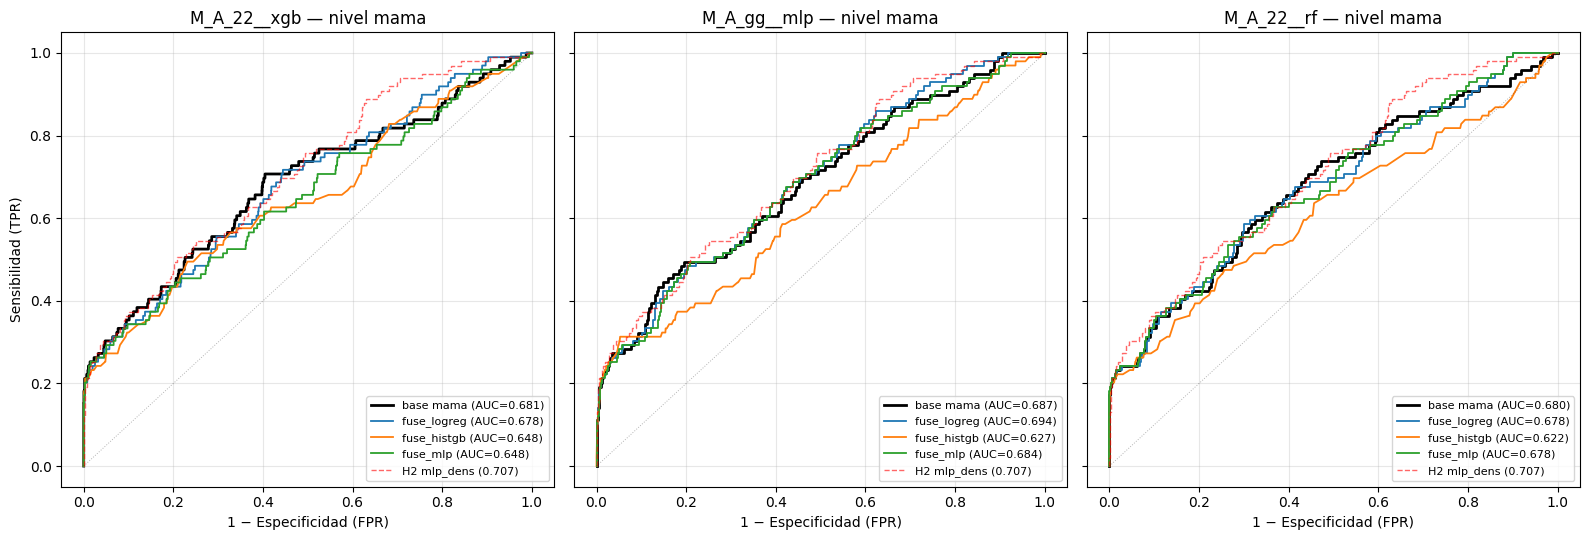

Guardado: fusion_mama_curvas_roc.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
colors = {'base': 'black', 'logreg': '#1f77b4', 'histgb': '#ff7f0e', 'mlp': '#2ca02c'}

for ax, (cfg, head) in zip(axes, CANDIDATOS):
    key = f'{cfg}__{head}'
    base = base_preds_M[key]['test']
    fpr, tpr, _ = roc_curve(y_M_test, base)
    auc = roc_auc_score(y_M_test, base)
    ax.plot(fpr, tpr, label=f'base mama (AUC={auc:.3f})', color=colors['base'], linewidth=2)
    for fm in FUSION_MODELS:
        pf = fusion_preds_M[f'{key}__fuse_{fm}']
        fpr_f, tpr_f, _ = roc_curve(y_M_test, pf)
        auc_f = roc_auc_score(y_M_test, pf)
        ax.plot(fpr_f, tpr_f, label=f'fuse_{fm} (AUC={auc_f:.3f})', color=colors[fm], linewidth=1.3)
    if pred_hito2_M is not None:
        fpr_h, tpr_h, _ = roc_curve(y_M_test, pred_hito2_M)
        ax.plot(fpr_h, tpr_h, '--', color='red', alpha=0.6, linewidth=1, label=f'H2 mlp_dens ({auc_hito2_M:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, linewidth=0.7)
    ax.set_xlabel('1 − Especificidad (FPR)')
    ax.set_title(f'{key} — nivel mama')
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('Sensibilidad (TPR)')
plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'fusion_mama_curvas_roc.png'), dpi=140, bbox_inches='tight')
plt.show()
print('Guardado: fusion_mama_curvas_roc.png')

## 10. Resumen ejecutivo

In [11]:
print('═' * 80)
print(' RESUMEN EJECUTIVO — NB11b fusión con densidad A NIVEL MAMA')
print('═' * 80)

print('\n1. AUC base por candidato A NIVEL MAMA (sin densidad):')
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    print(f'   {key:18s}  AUC mama = {base_preds_M[key]["auc_base_M"]:.4f}   '
          f'(agregado a estudio: {base_preds_M[key]["auc_base_E"]:.4f})')

print('\n2. Mejor fusión por candidato (a nivel mama):')
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    sub = df_fusion_M[(df_fusion_M.candidato == key) & (df_fusion_M.modelo_fusion != 'NINGUNO_base')]
    best = sub.nlargest(1, 'auc').iloc[0]
    base_auc = base_preds_M[key]['auc_base_M']
    sig = '★' if best['p_delong_vs_base'] < 0.05 else ' '
    print(f'  {sig}{key:18s}  fuse={best["modelo_fusion"]:<8s}  '
          f'AUC={best["auc"]:.4f}  (base={base_auc:.4f}, Δ={best["delta_vs_base"]:+.4f}, p={best["p_delong_vs_base"]:.4f})')

if auc_hito2_M is not None:
    print(f'\n3. Mejor fusión NB11b VS Hito 2 M_A_mlp_dens (AUC mama = {auc_hito2_M:.4f}):')
    df_h2_mama = pd.read_csv(os.path.join(PRED_DIR_V2, 'fusion_mama_vs_hito2.csv'))
    top5 = df_h2_mama.nlargest(5, 'auc_nb11b')
    for _, r in top5.iterrows():
        sig = '★' if r['p_delong'] < 0.05 else ' '
        print(f'  {sig}{r["candidato"]:18s} + fuse_{r["modelo_fusion"]:<8s}  '
              f'AUC={r["auc_nb11b"]:.4f}  (Δ vs H2={r["delta_nb11b_minus_h2"]:+.4f}, p={r["p_delong"]:.4f})')

print('\n4. CONCLUSIÓN — ¿la fusión con densidad ayuda a nivel mama (como afirmaba el Hito 2)?')
any_significant = (df_fusion_M[df_fusion_M.modelo_fusion != 'NINGUNO_base']['p_delong_vs_base'] < 0.05).sum()
positive_significant = ((df_fusion_M[df_fusion_M.modelo_fusion != 'NINGUNO_base']['p_delong_vs_base'] < 0.05) &
                        (df_fusion_M[df_fusion_M.modelo_fusion != 'NINGUNO_base']['delta_vs_base'] > 0)).sum()
print(f'   Comparaciones significativas (p<0.05):     {any_significant}/9')
print(f'   De ellas, con mejora (Δ>0):                {positive_significant}/9')

print('\n' + '═' * 80)
print(' Archivos generados:')
print('═' * 80)
for f in ['fusion_resultados_mama.csv', 'fusion_mama_vs_hito2.csv',
          'fusion_resultados_mama_agregadas.csv', 'fusion_mama_curvas_roc.png']:
    path = os.path.join(PRED_DIR_V2, f)
    exists = '✓' if os.path.isfile(path) else '✗'
    print(f'  {exists}  {f}')
n_files = len([f for f in os.listdir(FUSION_DIR_M) if f.endswith('_test.npy')])
print(f'  ✓  fusion_densidad_mama/ ({n_files} archivos *_test.npy)')

════════════════════════════════════════════════════════════════════════════════
 RESUMEN EJECUTIVO — NB11b fusión con densidad A NIVEL MAMA
════════════════════════════════════════════════════════════════════════════════

1. AUC base por candidato A NIVEL MAMA (sin densidad):
   M_A_22__xgb         AUC mama = 0.6813   (agregado a estudio: 0.6891)
   M_A_gg__mlp         AUC mama = 0.6866   (agregado a estudio: 0.6553)
   M_A_22__rf          AUC mama = 0.6803   (agregado a estudio: 0.6679)

2. Mejor fusión por candidato (a nivel mama):
   M_A_22__xgb         fuse=logreg    AUC=0.6784  (base=0.6813, Δ=-0.0029, p=0.8640)
   M_A_gg__mlp         fuse=logreg    AUC=0.6939  (base=0.6866, Δ=+0.0073, p=0.5722)
   M_A_22__rf          fuse=logreg    AUC=0.6781  (base=0.6803, Δ=-0.0022, p=0.8761)

3. Mejor fusión NB11b VS Hito 2 M_A_mlp_dens (AUC mama = 0.7067):
   M_A_gg__mlp        + fuse_logreg    AUC=0.6939  (Δ vs H2=-0.0128, p=0.5242)
   M_A_gg__mlp        + fuse_mlp       AUC=0.6841  (Δ vs H

## Siguientes pasos

Con NB11 y NB11b completos, tenemos evidencia completa sobre el efecto de la fusión con densidad en ambos niveles:
- **NB11**: fusión a nivel estudio (después de agregar con max)
- **NB11b**: fusión a nivel mama (antes de agregar)

El siguiente paso es:
- **NB12 — Calibración post-hoc** (Platt e isotónica) sobre el mejor candidato según los resultados conjuntos. Mejora Brier y ECE sin alterar AUC.
- Tras NB12, el experimental está completo y procede la **redacción definitiva** de los capítulos 4, 5 y 6 de la memoria.